## Paquid dataset application using the `jmstate` package

In [26]:
%pip install -q jmstate==0.14.1 pandas

Note: you may need to restart the kernel to use updated packages.


In [27]:
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import torch

In [28]:
torch.manual_seed(42)

paquid = pd.read_csv("../data/paquid.csv")

# Convert all numeric columns to float32
numeric_cols = paquid.select_dtypes(include="number").columns
paquid[numeric_cols] = paquid[numeric_cols].astype("float32")

In [ ]:
groups = paquid.groupby("ID")
ids = range(1, 501)
pad = torch.nn.utils.rnn.pad_sequence

trajectories, c, t, y, x = [], [], [], [], []

for i in ids:
    g = groups.get_group(i)

    s = g.groupby("HIER")["age"].min().reindex(range(4)).dropna()
    s = s[s >= s.cummax()]
    trajectories.append([((float(a) - 65) / 10, int(k)) for k, a in s.items()])

    c.append((g["age"].max() - 65) / 10)
    t.append((torch.tensor(g["age"].values) - 65) / 10)
    y.append(torch.tensor(g["MMSE"].values / 30))
    x.append(torch.tensor(g[["CEP", "male"]].iloc[0].values))

c = torch.tensor(c)[:, None]
t = pad(t, batch_first=True, padding_value=torch.nan)
y = pad(y, batch_first=True, padding_value=torch.nan)[..., None]
x = torch.stack(x)


In [30]:
from jmstate.utils import build_buckets

buckets = build_buckets(trajectories)
print({k: v.idxs.numel() for k, v in buckets.items()})

{(0, 1): 85, (0, 2): 44, (0, 3): 11, (1, 2): 135, (1, 3): 15, (2, 3): 86}


In [31]:
from jmstate.types import ModelDesign


def sigmoid(t: torch.Tensor, indiv_params: torch.Tensor):
    slope, offset = indiv_params.chunk(2, dim=-1)
    return torch.sigmoid((offset - t) / slope).unsqueeze(-1)


def f(fixed: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    x_aug = torch.cat([torch.ones(x.shape[0], 1), x], dim=-1)
    fixed = fixed.reshape(2, 3)

    indiv_params = x_aug @ fixed.T + b
    indiv_params[..., 0] = indiv_params[..., 0].exp()
    return indiv_params


# Define model design and link functions
link_fns = dict.fromkeys(buckets, sigmoid)
design = ModelDesign(f, sigmoid, link_fns)

In [32]:
from jmstate.types import ModelData
from sklearn.model_selection import train_test_split

(
    x_train,
    x_test,
    t_train,
    t_test,
    y_train,
    y_test,
    trajectories_train,
    trajectories_test,
    c_train,
    c_test,
) = train_test_split(x, t, y, trajectories, c, test_size=0.2, random_state=42)

data_train = ModelData(x_train, t_train, y_train, trajectories_train, c_train)
data_test = ModelData(x_test, t_test, y_test, trajectories_test, c_test)

In [33]:
from jmstate import MultiStateJointModel
from jmstate.functions.base_hazards import Weibull
from jmstate.types import ModelParameters, PrecisionParameters
from torch import nn

# Populate parameters sharing the same memory address
shared_x_coef = nn.Parameter(torch.zeros(2))

params = ModelParameters(
    torch.zeros(6),
    PrecisionParameters.from_covariance(torch.eye(2), "full"),
    PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
    {key: Weibull(1.0, 1.0) for key in buckets},
    {key: torch.zeros(1) for key in buckets},
    dict.fromkeys(buckets, shared_x_coef),
)

optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
model = MultiStateJointModel(design, params, optimizer).fit(data_train)

Fitting joint model: 100%|██████████| 1000/1000 [00:39<00:00, 25.25it/s]
/home/flheight/Documents/venv/lib/python3.13/site-packages/jmstate/model/_fit.py:285: UserWarning: Model may not have converged in the specified number of iterations. Try to increase `max_iter_fit`, `tol`, or `window_size`. Also try to increase `n_subsample` or `n_warmup` for better MCMC mixing.
  self._fit(data, sampler)
Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:16<00:00,  6.02it/s]


╭───────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃  Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │  0.079  │     0.096      │  0.816  │  0.414  │                    │ │
│ │ fixed_effects[1]                │ -0.348  │     0.106      │  3.288  │  0.001  │         **         │ │
│ │ fixed_effects[2]                │  0.308  │     0.106      │  2.903  │  0.004  │         **         │ │
│ │ fixed_effects[3]                │  3.983  │     0.160      │ 24.918  │  0.000  │        ***         │ │
│ │ fixed_effects[4]                │  0.115  │     0.183      │  0.630  │  0.529  │                    │ │
│ │ fixed_effects[5]                │  0.495  │     0.200      │  2.482  │  0.013  │         *          │ │
│ │ random_prec.flat[0]             │  0.786  │     0.056      │ 14.017  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]             │ -1.155  │     0.118      │  9.820  │  0.000  │        ***         │ │
│ │ random_prec.flat[2]             │ -0.286  │     0.083      │  3.467  │  0.001  │        ***         │ │
│ │ noise_prec.flat[0]              │  2.875  │     0.008      │ 341.954 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.361  │     1.198      │  1.136  │  0.256  │                    │ │
│ │ base_hazards.(0, 1).log_k[0]    │  0.234  │     0.147      │  1.595  │  0.111  │                    │ │
│ │ base_hazards.(0, 2).log_lmda[0] │  1.616  │     0.522      │  3.097  │  0.002  │         **         │ │
│ │ base_hazards.(0, 2).log_k[0]    │  0.705  │     0.151      │  4.673  │  0.000  │        ***         │ │
│ │ base_hazards.(0, 3).log_lmda[0] │  2.940  │     1.709      │  1.720  │  0.085  │         .          │ │
│ │ base_hazards.(0, 3).log_k[0]    │  0.708  │     0.499      │  1.418  │  0.156  │                    │ │
│ │ base_hazards.(1, 2).log_lmda[0] │  1.312  │     0.561      │  2.338  │  0.019  │         *          │ │
│ │ base_hazards.(1, 2).log_k[0]    │  0.444  │     0.111      │  4.016  │  0.000  │        ***         │ │
│ │ base_hazards.(1, 3).log_lmda[0] │  2.645  │     0.940      │  2.814  │  0.005  │         **         │ │
│ │ base_hazards.(1, 3).log_k[0]    │  0.488  │     0.299      │  1.636  │  0.102  │                    │ │
│ │ base_hazards.(2, 3).log_lmda[0] │  2.260  │     0.406      │  5.570  │  0.000  │        ***         │ │
│ │ base_hazards.(2, 3).log_k[0]    │  0.534  │     0.109      │  4.909  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │  1.417  │     1.705      │  0.831  │  0.406  │                    │ │
│ │ link_coefs.(0, 2)[0]            │ -5.005  │     1.162      │  4.307  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 3)[0]            │ -11.232 │     2.401      │  4.678  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0]            │ -2.375  │     0.958      │  2.480  │  0.013  │         *          │ │
│ │ link_coefs.(1, 3)[0]            │ -7.850  │     1.007      │  7.797  │  0.000  │        ***         │ │
│ │ link_coefs.(2, 3)[0]            │ -5.387  │     0.658      │  8.181  │  0.000  │        ***         │ │
│ │ x_coefs.(0, 1)[0]               │ -0.133  │     0.348      │  0.382  │  0.702  │                    │ │
│ │ x_coefs.(0, 1)[1]               │  0.243  │     0.253      │  0.959  │  0.337  │                    │ │
│ └─────────────────────────────────┴─────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: 1704.149                                                                                │
│ AI

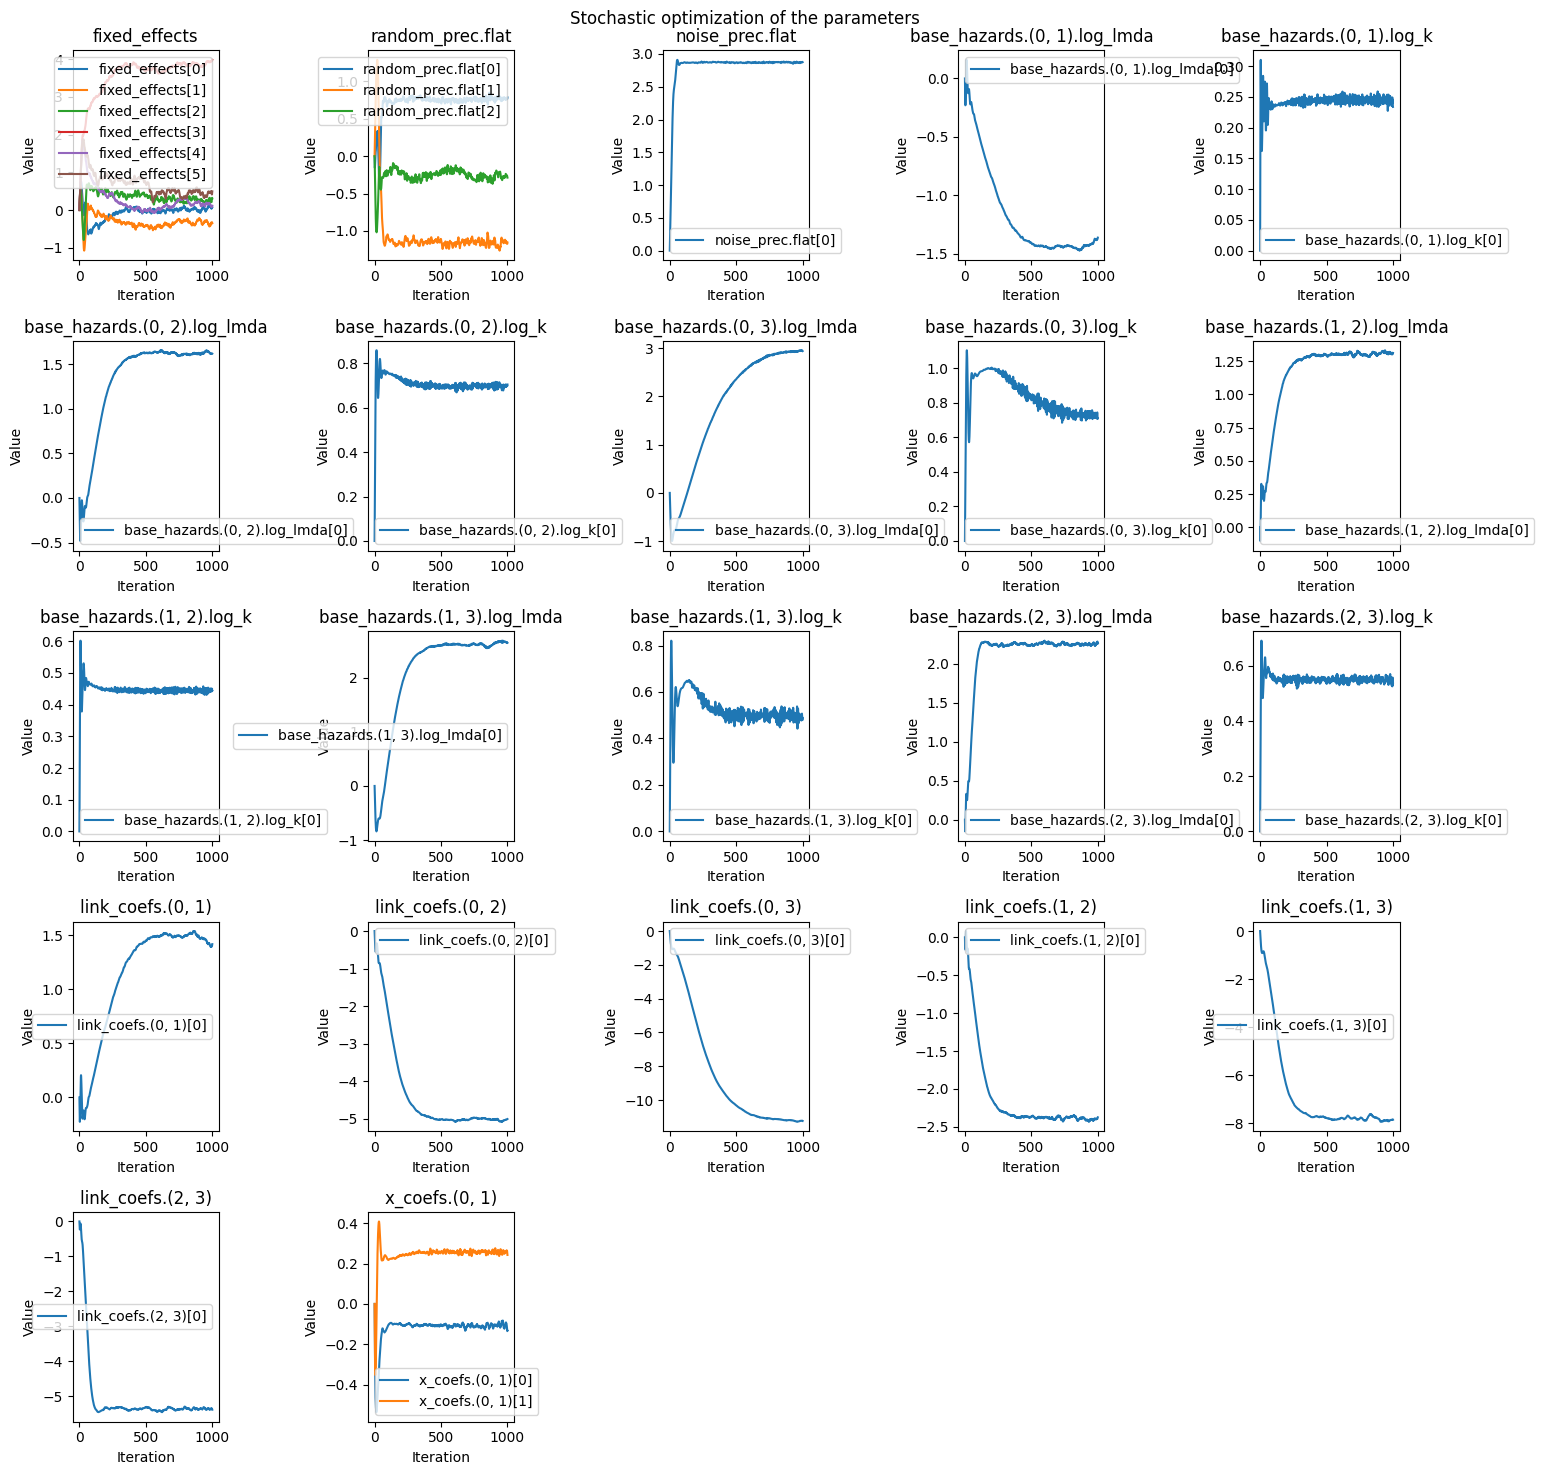

In [34]:
from jmstate.utils import plot_params_history, summary

summary(model)

plot_params_history(model, figsize=(15, 15))
plt.show()

In [35]:
print(model.params.fixed_effects.flatten())

Parameter containing:
tensor([ 0.0786, -0.3481,  0.3080,  3.9825,  0.1151,  0.4954],
       requires_grad=True)


tensor([[0.6989, 0.9333],
        [0.9333, 1.7730]], grad_fn=<CholeskyInverseBackward0>)


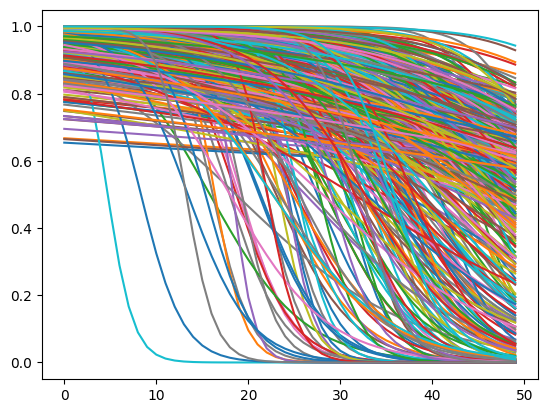

In [50]:
from torch.distributions import MultivariateNormal

Q = params.random_prec.covariance
gamma = params.fixed_effects
print(Q)

# Create and sample from distribution
dist = MultivariateNormal(torch.zeros(Q.size(0)), Q)

b = dist.sample((500,))
psi = design.indiv_params_fn(gamma, x, b)

# Generates random evaluations points with a minimum distance
t = torch.linspace(0, 4, 50)
y = design.regression_fn(t, psi)

plt.plot(y.detach().squeeze(-1).T)
plt.show()


In [91]:
from dataclasses import replace


def predict_trunc(trunc_time: float):
    trajectories_trunc = [
        [traj[0]] + [(t, s) for (t, s) in traj[1:] if t <= trunc_time]
        for traj in data_test.trajectories
    ]
    c = torch.tensor([traj[-1][0] for traj in data_test.trajectories])[:, None]
    trunc_y = data_test.y.clone()
    trunc_y[data_test.t > trunc_time] = torch.nan

    data_test_trunc = replace(
        data_test,
        y=trunc_y,
        trajectories=trajectories_trunc,
        c=torch.maximum(c, trunc_time),
    )
    return model.predict_trajectories(
        data_test_trunc, c=data_test_trunc.c, n_samples=100
    )


def hier_probs(
    pred_trajectories: list[list[list[tuple[float, Any]]]],
    u: torch.Tensor,
):
    counts = torch.zeros(len(pred_trajectories[0]), 4)
    num_sets = len(pred_trajectories)

    for trajectories in pred_trajectories:
        for i, trajectory in enumerate(trajectories):
            last_valid_state = trajectory[0][1]

            for t, s in reversed(trajectory):
                if t <= u:
                    last_valid_state = s
                    break

            counts[i][last_valid_state] += 1

    return counts / num_sets


def normalized_brier(pred_probs: torch.Tensor, real_probs: torch.Tensor):
    bs_model = ((pred_probs - real_probs) ** 2).mean()

    baseline = real_probs.mean(dim=0, keepdim=True)
    bs_baseline = ((baseline - real_probs) ** 2).mean()

    return 1 - (bs_model / bs_baseline).item()

Predicting trajectories: 100%|██████████| 20/20 [00:03<00:00,  5.19it/s]


[1.0, 0.7599039971828461, 0.35616040229797363, -0.3992258310317993, -0.5763829946517944, -0.5656135082244873]


/tmp/ipykernel_4963/510363696.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


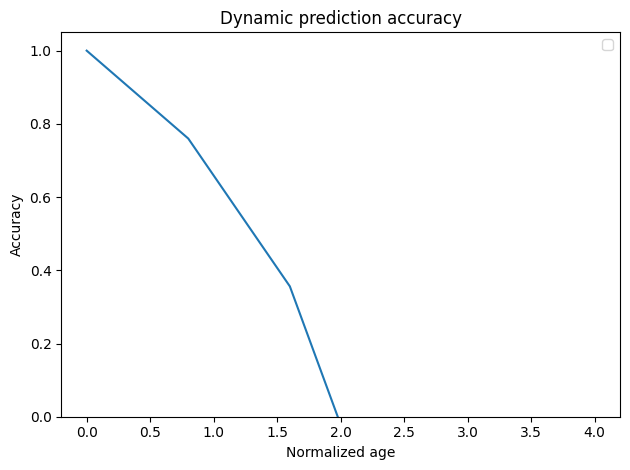

In [92]:
trunc_times = torch.linspace(0, data_test.t.nanquantile(1), 1)
us = torch.linspace(0, 4, 6)

for trunc_time in trunc_times:
    pred_trajectories = predict_trunc(trunc_time)

    pred_probs = [hier_probs(pred_trajectories, u) for u in us]
    real_states = [hier_probs([data_test.trajectories], u) for u in us]

    accuracy = [
        normalized_brier(pred_prob, real_state)
        for real_state, pred_prob in zip(real_states, pred_probs, strict=True)
    ]

    print(accuracy)

    plt.plot(
        us,
        accuracy,
    )


plt.ylim(0, 1.05)
plt.title("Dynamic prediction accuracy")
plt.xlabel("Normalized age")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/paquid-accuracy.pdf")
plt.show()

In [ ]:
print(accuracy)

[tensor(0.), tensor(0.), tensor(0.), tensor(0.), tensor(0.)]
